# 📊 🏦 BANKING CUSTOMER ANALYTICS – EDA PROJECT

# 1. PROBLEM STATEMENT

## Objective of this project:
### To analyze banking customer data and understand patterns in income, loans, credit scores, and risk behavior.
### The goal is to identify high-risk customers and key financial drivers influencing customer value.

# 2. IMPORTING LIBRARIES (DATASET SETUP)

In [19]:
# Install required package (run once in Jupyter)
# pip install mysql-connector-python

# Import required libraries for database connection and data analysis

import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Set visualization style

sns.set(style="whitegrid")

# 3. DATA LOADING (SQL CONNECTION)

In [26]:
# Establish connection to MySQL database
cnx = mysql.connector.connect(
    host="127.0.0.1",
    port=3306,
    user="root",
    password="sql@162",
    auth_plugin='mysql_native_password'
)

# SQL query to extract customer data
query = "SELECT * FROM banking.customer"

# Load data into pandas DataFrame
df = pd.read_sql(query, cnx)

# Close connection after fetching data
cnx.close()

# Display first rows
df.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_26116\1417433443.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, cnx)


,Customer_ID,Customer_name,Gender,Age,Age_Group,Location_Code,Account_ID,Onboarding_Date,Relationship_manager,Region,...,Saving_Accounts,Net_Worth,Forex_Account,Business_Lending,Properties_Owned,Risk_Score,Risk_Category,Branch_Code,Branch_type,Branch_name
0,IND00001,Raymond Mills,male,24,Young,34324,ACC0001,06-05-2019,Anthony Torres,America,...,607332.46,1920536.06,12249.96,1134475.30,1,2,Medium Risk,BR001,Retail,New York Downtown
1,IND00002,Julia Spencer,male,23,Young,42205,ACC0002,10-12-2001,Jonathan Hawkins,Africa,...,344635.16,-54976.11,61162.31,2000526.10,1,3,Medium Risk,BR002,Institutional,London Canary Wharf
2,IND00003,Stephen Murray,female,27,Adult,7314,ACC0003,25-01-2010,Anthony Berry,Europe,...,203054.35,836414.79,79071.78,548137.58,1,3,Medium Risk,BR003,Private,Singapore Marina Bay
3,IND00004,Virginia Garza,male,40,Middle Age,34594,ACC0004,28-03-2019,Steve Diaz,America,...,234685.02,2209804.94,57513.65,1148402.29,0,4,Medium Risk,BR004,Commercial,Dubai DIFC
4,IND00005,Melissa Sanders,female,46,Middle Age,41269,ACC0005,20-07-2012,Shawn Long,America,...,128351.45,14476.28,30012.14,1674412.12,0,3,Medium Risk,BR001,Retail,New York Downtown


# 4. DATA UNDERSTANDING (OVERVIEW)

In [31]:
# Check structure of dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Customer_ID              6000 non-null   object 
 1   Customer_name            6000 non-null   object 
 2   Gender                   6000 non-null   object 
 3   Age                      6000 non-null   int64  
 4   Age_Group                6000 non-null   object 
 5   Location_Code            6000 non-null   int64  
 6   Account_ID               6000 non-null   object 
 7   Onboarding_Date          6000 non-null   object 
 8   Relationship_manager     6000 non-null   object 
 9   Region                   6000 non-null   object 
 10  Country                  6000 non-null   object 
 11  Occupation               6000 non-null   object 
 12  Fee_Plan                 6000 non-null   object 
 13  Loyalty_Status           6000 non-null   object 
 14  Annual_Income           

Index(['Customer_ID', 'Customer_name', 'Gender', 'Age', 'Age_Group',
       'Location_Code', 'Account_ID', 'Onboarding_Date',
       'Relationship_manager', 'Region', 'Country', 'Occupation', 'Fee_Plan',
       'Loyalty_Status', 'Annual_Income', 'Retirement_Savings',
       'No_of_Credit_Cards', 'Credit_Card_Outstanding', 'Loan_amount', 'DTI',
       'Bank_Deposits', 'Credit_Score', 'Checking_Accounts', 'Saving_Accounts',
       'Net_Worth', 'Forex_Account', 'Business_Lending', 'Properties_Owned',
       'Risk_Score', 'Risk_Category', 'Branch_Code', 'Branch_type',
       'Branch_name'],
      dtype='object')

In [33]:
# Summary statistics

df.describe()

,Age,Location_Code,Annual_Income,Retirement_Savings,No_of_Credit_Cards,Credit_Card_Outstanding,Loan_amount,DTI,Bank_Deposits,Credit_Score,Checking_Accounts,Saving_Accounts,Net_Worth,Forex_Account,Business_Lending,Properties_Owned,Risk_Score
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6.000000e+03,6000.00000,6.000000e+03,6000.000000,6.000000e+03,6.000000e+03,6.000000e+03,6000.000000,6.000000e+03,6000.000000,6000.000000
mean,51.304667,21563.323000,171305.034263,25531.599673,1.463667,3176.206943,5.913862e+05,0.04726,6.715602e+05,667.808000,3.210929e+05,2.329084e+05,6.341753e+05,29883.529993,8.667598e+05,1.518667,2.249333
std,19.875505,12461.234277,111926.478282,16258.595491,0.676330,2496.886574,4.575189e+05,0.04625,6.456630e+05,76.108983,2.820560e+05,2.299886e+05,9.987488e+05,23107.997782,6.411769e+05,1.102053,1.131097
min,17.000000,12.000000,15919.480000,1482.030000,1.000000,1.170000,0.000000e+00,0.00000,0.000000e+00,550.000000,0.000000e+00,0.000000e+00,-1.823117e+06,45.000000,0.000000e+00,0.000000,1.000000
25%,34.000000,10803.500000,82906.595000,12513.775000,1.000000,1236.630000,2.396281e+05,0.02000,2.044004e+05,606.000000,1.199475e+05,7.479440e+04,6.322270e+03,11916.542500,3.748251e+05,1.000000,1.000000
50%,51.000000,21129.500000,142313.480000,22357.355000,1.000000,2560.805000,4.797934e+05,0.03000,4.633165e+05,662.000000,2.428157e+05,1.640866e+05,4.067761e+05,24341.190000,7.113147e+05,2.000000,2.000000
75%,69.000000,32054.500000,242290.305000,35464.740000,2.000000,4522.632500,8.258130e+05,0.06000,9.427546e+05,718.000000,4.348749e+05,3.155750e+05,1.085349e+06,41966.392500,1.185110e+06,2.000000,3.000000
max,85.000000,43369.000000,522330.260000,75963.900000,3.000000,13991.990000,2.667557e+06,0.41000,3.890598e+06,900.000000,1.969923e+06,1.724118e+06,5.903501e+06,124704.870000,3.825962e+06,3.000000,5.000000


In [35]:
# Check column names

df.columns

Index(['Customer_ID', 'Customer_name', 'Gender', 'Age', 'Age_Group',
       'Location_Code', 'Account_ID', 'Onboarding_Date',
       'Relationship_manager', 'Region', 'Country', 'Occupation', 'Fee_Plan',
       'Loyalty_Status', 'Annual_Income', 'Retirement_Savings',
       'No_of_Credit_Cards', 'Credit_Card_Outstanding', 'Loan_amount', 'DTI',
       'Bank_Deposits', 'Credit_Score', 'Checking_Accounts', 'Saving_Accounts',
       'Net_Worth', 'Forex_Account', 'Business_Lending', 'Properties_Owned',
       'Risk_Score', 'Risk_Category', 'Branch_Code', 'Branch_type',
       'Branch_name'],
      dtype='object')

# 5. DATA CLEANING

In [40]:
# Remove extra spaces and fix column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(' ', '_')
df.columns = df.columns.str.replace('(', '')
df.columns = df.columns.str.replace(')', '')
df.columns = df.columns.str.replace('-', '_')
df.columns = df.columns.str.replace('ï»¿', '')

In [42]:
# Check missing values
df.isnull().sum()

Customer_ID                0
Customer_name              0
Gender                     0
Age                        0
Age_Group                  0
Location_Code              0
Account_ID                 0
Onboarding_Date            0
Relationship_manager       0
Region                     0
Country                    0
Occupation                 0
Fee_Plan                   0
Loyalty_Status             0
Annual_Income              0
Retirement_Savings         0
No_of_Credit_Cards         0
Credit_Card_Outstanding    0
Loan_amount                0
DTI                        0
Bank_Deposits              0
Credit_Score               0
Checking_Accounts          0
Saving_Accounts            0
Net_Worth                  0
Forex_Account              0
Business_Lending           0
Properties_Owned           0
Risk_Score                 0
Risk_Category              0
Branch_Code                0
Branch_type                0
Branch_name                0
dtype: int64

In [132]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [134]:
# Convert onboarding date into proper datetime format
df['Onboarding_Date'] = pd.to_datetime(
    df['Onboarding_Date'],
    format='%d-%m-%Y',
    errors='coerce'
)

In [136]:
# Verify data
df.head()

,Customer_ID,Customer_name,Gender,Age,Age_Group,Location_Code,Account_ID,Onboarding_Date,Relationship_manager,Region,...,Risk_Score,Risk_Category,Branch_Code,Branch_type,Branch_name,Age_Band,Engagement_Score,Total_Value,Risk_Flag,Income_Segment
0,IND00001,Raymond Mills,male,24,Young,34324,ACC0001,2019-05-06,Anthony Torres,America,...,2,Medium Risk,BR001,Retail,New York Downtown,Young,1210951.34,3406364.70,Normal,Low
1,IND00002,Julia Spencer,male,23,Young,42205,ACC0002,2001-12-10,Jonathan Hawkins,Africa,...,3,Medium Risk,BR002,Institutional,London Canary Wharf,Young,574157.53,586506.68,Normal,Very High
2,IND00003,Stephen Murray,female,27,Adult,7314,ACC0003,2010-01-25,Anthony Berry,Europe,...,3,Medium Risk,BR003,Private,Singapore Marina Bay,Mid-age,855731.04,1869816.38,Normal,High
3,IND00004,Virginia Garza,male,40,Middle Age,34594,ACC0004,2019-03-28,Steve Diaz,America,...,4,Medium Risk,BR004,Commercial,Dubai DIFC,Mid-age,1282844.51,3257962.43,Normal,Very High
4,IND00005,Melissa Sanders,female,46,Middle Age,41269,ACC0005,2012-07-20,Shawn Long,America,...,3,Medium Risk,BR001,Retail,New York Downtown,Senior,574996.70,502258.81,Normal,Mid


# 6. FEATURE ENGINEERING

In [138]:
# Create age groups for better segmentation

df['Age_Band'] = pd.cut(df['Age'],
                       bins=[0,25,45,100],
                       labels=['Young','Mid-age','Senior'])

In [57]:
# Customer engagement score
df['Engagement_Score'] = (
    df['Checking_Accounts'] +
    df['Saving_Accounts'] +
    df['No_of_Credit_Cards']
)

In [59]:
# Total financial value
df['Total_Value'] = df['Bank_Deposits'] + df['Net_Worth']

In [67]:
# Risk flag creation
df['Risk_Flag'] = df.apply(
    lambda x: 'High Risk' if x['Risk_Score'] >= 4 and x['Credit_Score'] < 600 else 'Normal',
    axis=1
)

In [69]:
# Income segmentation
df['Income_Segment'] = pd.qcut(
    df['Annual_Income'],
    4,
    labels=['Low','Mid','High','Very High']
)

In [71]:
df.head()

,Customer_ID,Customer_name,Gender,Age,Age_Group,Location_Code,Account_ID,Onboarding_Date,Relationship_manager,Region,...,Risk_Score,Risk_Category,Branch_Code,Branch_type,Branch_name,Age_Band,Engagement_Score,Total_Value,Risk_Flag,Income_Segment
0,IND00001,Raymond Mills,male,24,Young,34324,ACC0001,2019-05-06,Anthony Torres,America,...,2,Medium Risk,BR001,Retail,New York Downtown,Young,1210951.34,3406364.70,Normal,Low
1,IND00002,Julia Spencer,male,23,Young,42205,ACC0002,2001-12-10,Jonathan Hawkins,Africa,...,3,Medium Risk,BR002,Institutional,London Canary Wharf,Young,574157.53,586506.68,Normal,Very High
2,IND00003,Stephen Murray,female,27,Adult,7314,ACC0003,2010-01-25,Anthony Berry,Europe,...,3,Medium Risk,BR003,Private,Singapore Marina Bay,Mid-age,855731.04,1869816.38,Normal,High
3,IND00004,Virginia Garza,male,40,Middle Age,34594,ACC0004,2019-03-28,Steve Diaz,America,...,4,Medium Risk,BR004,Commercial,Dubai DIFC,Mid-age,1282844.51,3257962.43,Normal,Very High
4,IND00005,Melissa Sanders,female,46,Middle Age,41269,ACC0005,2012-07-20,Shawn Long,America,...,3,Medium Risk,BR001,Retail,New York Downtown,Senior,574996.70,502258.81,Normal,Mid


# 7. UNIVARIATE ANALYSIS

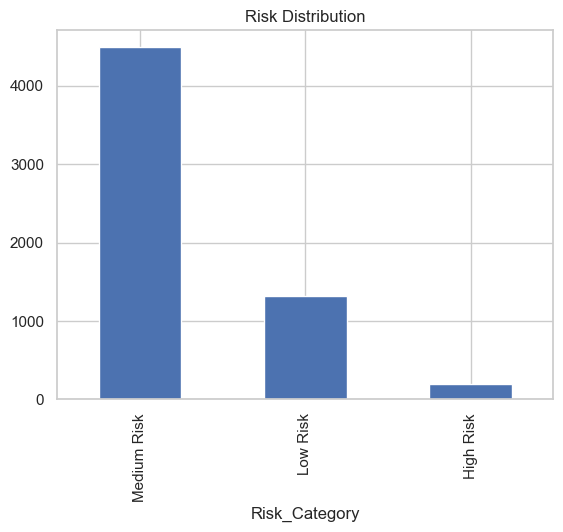

In [74]:
# Risk category distribution
df['Risk_Category'].value_counts().plot(kind='bar')
plt.title("Risk Distribution")
plt.show()

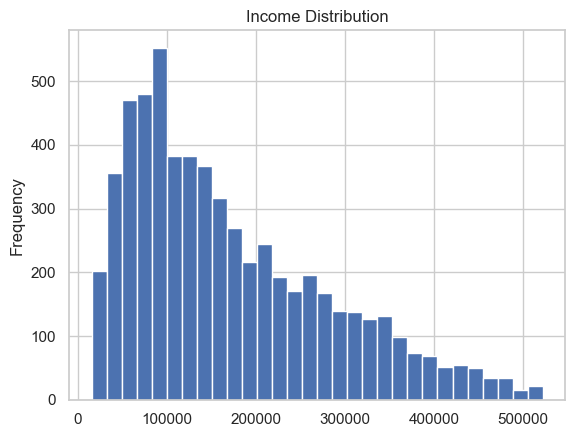

In [76]:
# Income distribution
df['Annual_Income'].plot(kind='hist', bins=30)
plt.title("Income Distribution")
plt.show()

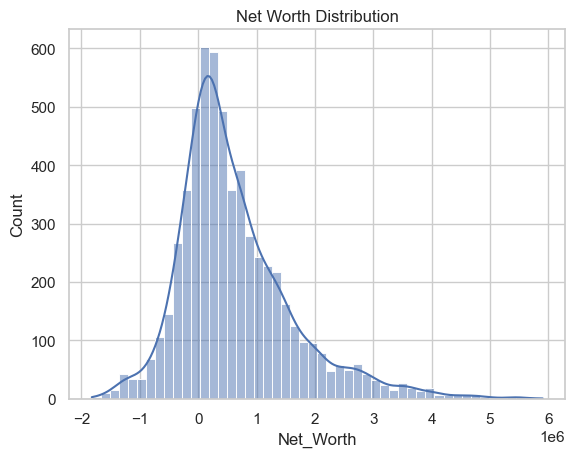

In [78]:
# Net worth distribution
sns.histplot(df['Net_Worth'], bins=50, kde=True)
plt.title("Net Worth Distribution")
plt.show()

# INSIGHT (Univariate)

## Insight:
### Most customers fall into Normal risk category
### Income is right-skewed (few high-income customers)
### Net worth shows wide variation across customers

# 8. BIVARIATE ANALYSIS (RELATIONSHIPS)

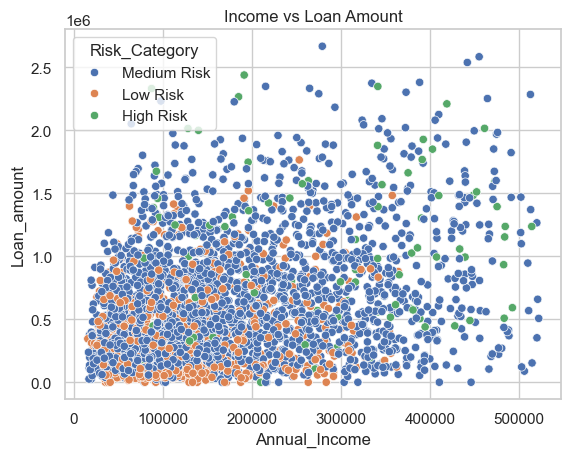

In [87]:
# Income vs Loan Amount
sns.scatterplot(x='Annual_Income', y='Loan_amount', hue='Risk_Category', data=df)
plt.title("Income vs Loan Amount")
plt.show()

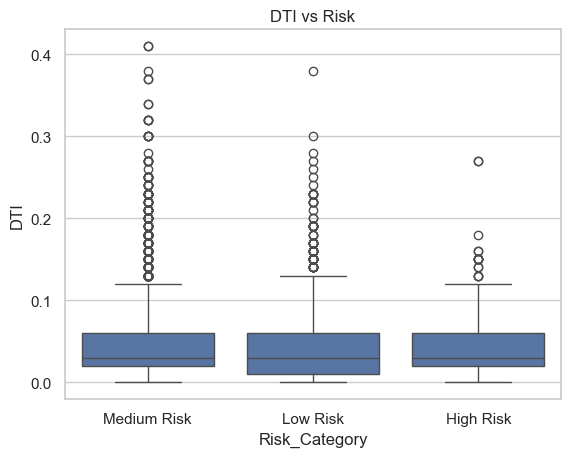

In [93]:
# DTI vs Risk
sns.boxplot(x='Risk_Category', y='DTI', data=df)
plt.title("DTI vs Risk")
plt.show()

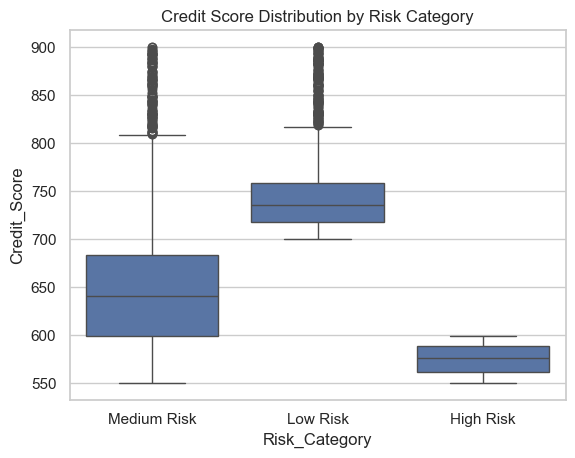

In [95]:
# Credit Score by Risk
sns.boxplot(x='Risk_Category', y='Credit_Score', data=df)
plt.title("Credit Score Distribution by Risk Category")
plt.show()

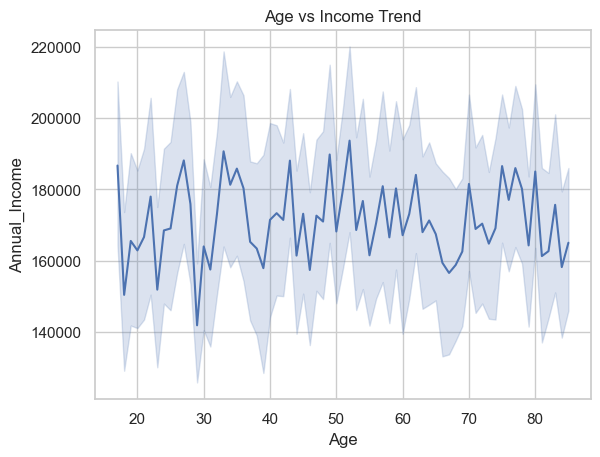

In [97]:
# Age vs Income trend
sns.lineplot(x='Age', y='Annual_Income', data=df)
plt.title("Age vs Income Trend")
plt.show()

# INSIGHT (Bivariate)

### 9. MULTIVARIATE ANALYSIS (CORRELATION)

In [102]:
# Correlation matrix
df.corr(numeric_only=True)

,Age,Location_Code,Annual_Income,Retirement_Savings,No_of_Credit_Cards,Credit_Card_Outstanding,Loan_amount,DTI,Bank_Deposits,Credit_Score,Checking_Accounts,Saving_Accounts,Net_Worth,Forex_Account,Business_Lending,Properties_Owned,Risk_Score,Engagement_Score,Total_Value
Age,1.000000,-0.005541,0.001814,-0.017817,-0.005141,0.008855,0.005158,-0.006855,-0.001574,0.006532,0.000303,-0.000659,-0.003447,-0.008508,-0.003487,0.002495,-0.000881,-0.000151,-0.002787
Location_Code,-0.005541,1.000000,-0.014235,-0.002113,-0.010115,-0.015764,-0.019554,0.007902,-0.032282,-0.001968,-0.030547,0.003305,-0.019778,-0.011679,0.000477,-0.035176,0.007579,-0.017926,-0.025376
Annual_Income,0.001814,-0.014235,1.000000,0.374802,-0.038399,0.298527,0.329926,-0.423189,0.260332,0.086937,0.291412,0.261299,0.159629,0.306999,0.328531,-0.008175,0.664726,0.324675,0.204724
Retirement_Savings,-0.017817,-0.002113,0.374802,1.000000,-0.039416,0.225562,0.241457,-0.080104,0.174084,-0.002909,0.198188,0.177132,0.098690,0.228103,0.264919,0.024669,0.499640,0.220507,0.131871
No_of_Credit_Cards,-0.005141,-0.010115,-0.038399,-0.039416,1.000000,-0.021644,0.000067,0.025168,-0.025614,-0.000304,-0.017295,-0.031438,-0.028714,-0.018598,-0.018311,0.002476,-0.027378,-0.027627,-0.028264
Credit_Card_Outstanding,0.008855,-0.015764,0.298527,0.225562,-0.021644,1.000000,0.369509,0.047805,0.383877,0.008902,0.298672,0.284696,0.228803,0.357720,0.351063,0.002354,0.399694,0.341626,0.297771
Loan_amount,0.005158,-0.019554,0.329926,0.241457,0.000067,0.369509,1.000000,0.470833,0.373155,-0.237654,0.292082,0.268882,-0.072454,0.364391,0.417095,0.014687,0.421824,0.329086,0.105369
DTI,-0.006855,0.007902,-0.423189,-0.080104,0.025168,0.047805,0.470833,1.000000,0.087184,-0.197686,0.011215,0.016238,-0.152417,0.059946,0.065274,-0.007042,-0.127462,0.015739,-0.059967
Bank_Deposits,-0.001574,-0.032282,0.260332,0.174084,-0.025614,0.383877,0.373155,0.087184,1.000000,0.033028,0.844278,0.754744,0.887765,0.406347,0.441298,-0.013553,0.345412,0.939446,0.957822
Credit_Score,0.006532,-0.001968,0.086937,-0.002909,-0.000304,0.008902,-0.237654,-0.197686,0.033028,1.000000,0.060320,0.052397,0.159320,-0.010877,-0.015395,-0.011428,0.029408,0.066318,0.112793


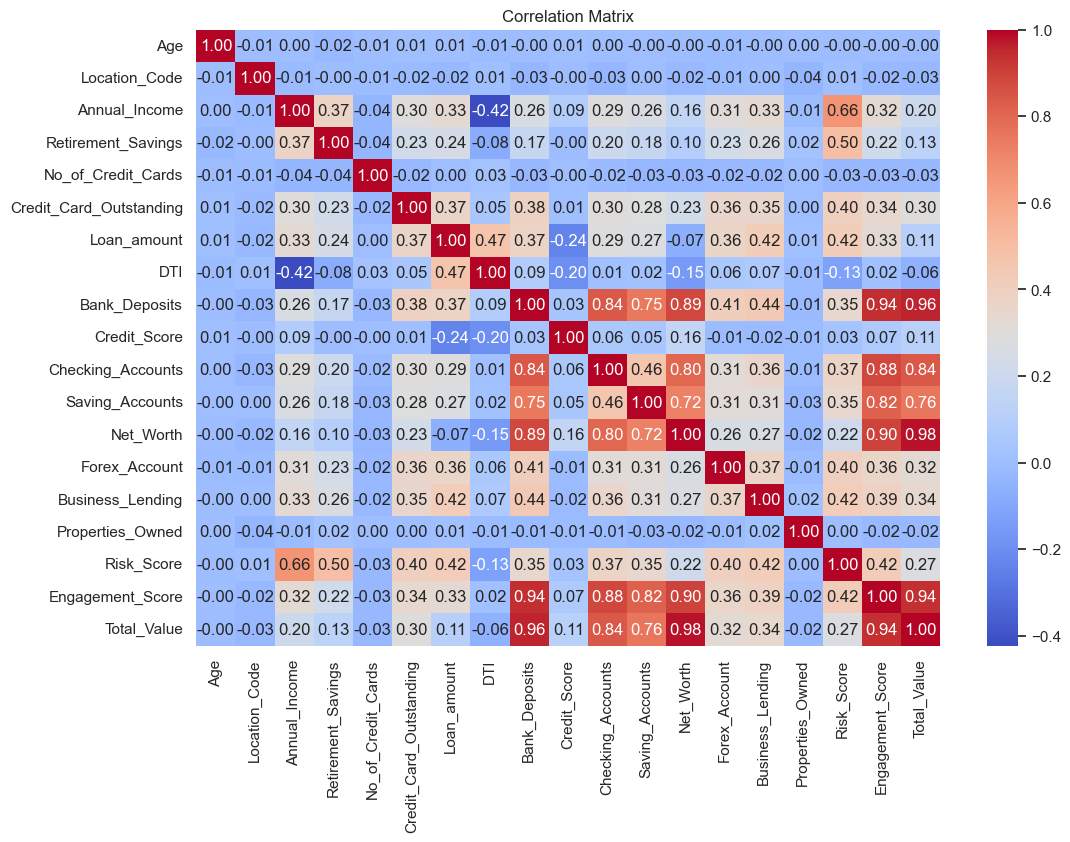

In [104]:
# Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# INSIGHT (Correlation)

## Strong positive correlation:

### Income ↔ Net Worth
### Loan Amount ↔ Income

## Strong negative correlation:
### Credit Score ↔ Risk Score

# 10. ADVANCED VISUALS

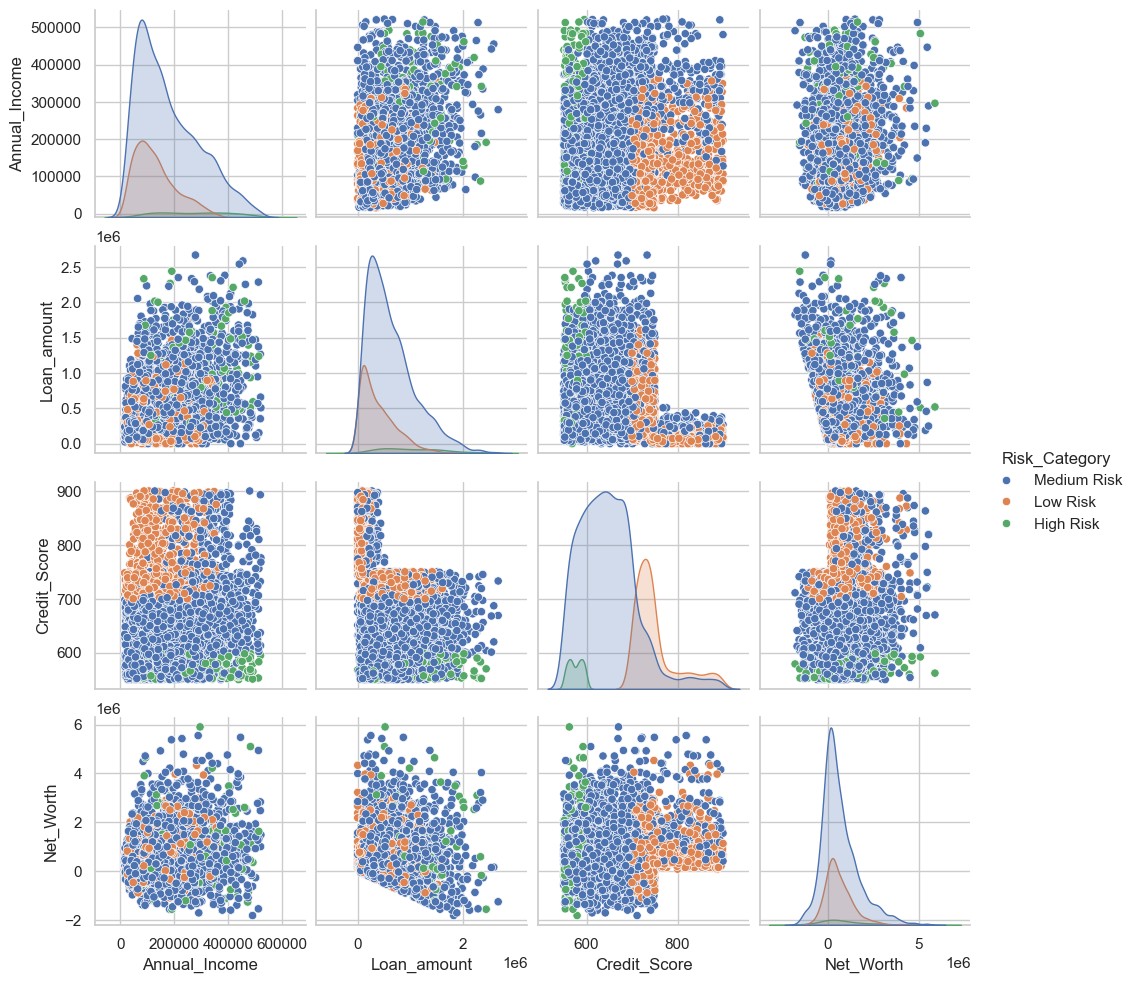

In [115]:
# Pairplot
cols = ['Annual_Income','Loan_amount','Credit_Score','Net_Worth','Risk_Category']
sns.pairplot(df[cols].dropna(), hue='Risk_Category')
plt.show()

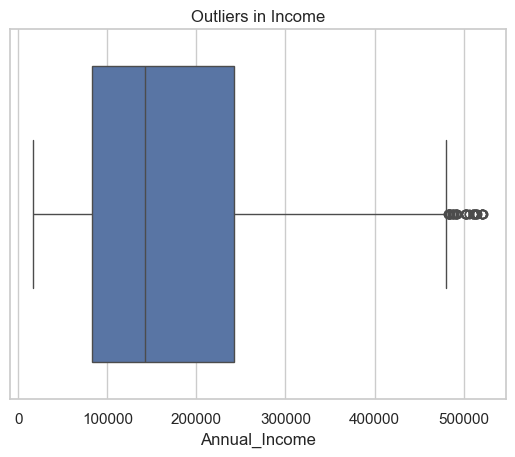

In [112]:
# Boxplot for outliers
sns.boxplot(x=df['Annual_Income'])
plt.title("Outliers in Income")
plt.show()

# 11. SEGMENT ANALYSIS

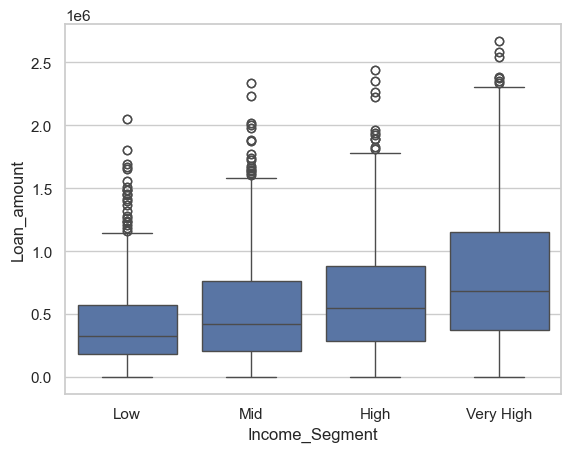

In [118]:
# Income vs Loan by segment
sns.boxplot(x='Income_Segment', y='Loan_amount', data=df)
plt.show()

# 12. FINAL BUSINESS INSIGHTS

# FINAL INSIGHTS:

### 1. High-income customers hold significantly higher loan amounts
### 2. Credit score is a strong indicator of customer risk level
### 3. Debt-to-income ratio is highest among high-risk customers
### 4. Engagement score helps identify loyal/high-value customers
### 5. Income and net worth are strongly positively correlated

# BUSINESS IMPACT:

### - Bank can target high-value customers for premium services
### - Risk-based lending strategy can reduce defaults
### - Engagement score can be used for cross-selling opportunities

# 13. SAVE CLEAN DATASET

In [130]:
# Save cleaned dataset for future ML or reporting
df.to_csv("cleaned_banking_data.csv", index=False)